In [ ]:
import numpy as np
from collections import Counter

class KNNClassifier:
    
    def __init__(self, k=3):
        self.k = k
        
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
        
    def euclidean_distance(self, x1, x2):
        return np.sqrt(np.sum((x1 - x2)**2))
    
    def predict(self, X):
        predictions = [self._predict(x) for x in X]
        return np.array(predictions)
    
    def _predict(self, x):
        
        
        distances = [self.euclidean_distance(x, x_train)
                     for x_train in self.X_train]
        
        
        k_indices = np.argsort(distances)[:self.k]
        
        
        k_nearest_labels = [self.y_train[i] for i in k_indices]
        
       
        most_common = Counter(k_nearest_labels).most_common(1)
        return most_common[0][0]

In [4]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X, y = make_classification(
    n_samples=500,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_repeated=0,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = KNNClassifier(k=5)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions))

Accuracy: 0.91


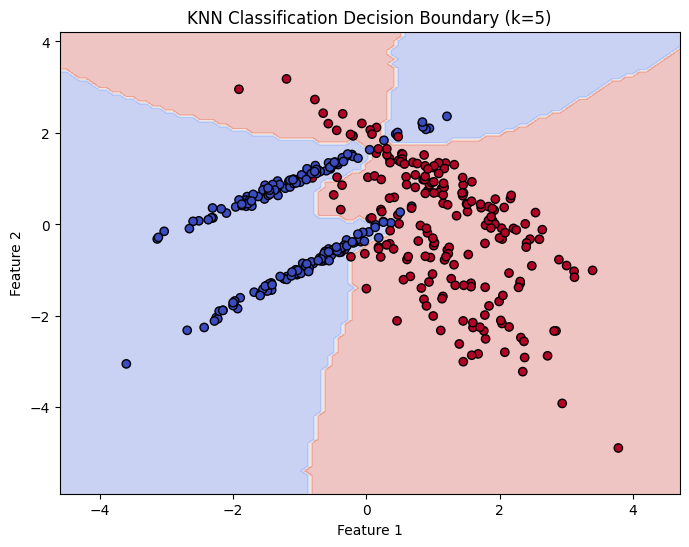

In [ ]:

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)


plt.figure(figsize=(8,6))


plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)


plt.scatter(X_train[:, 0], X_train[:, 1], 
            c=y_train, cmap=plt.cm.coolwarm, edgecolors='k')

plt.title(f"KNN Classification Decision Boundary (k={model.k})")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()